# WA EV Infrastructure Analysis

This project's goal is to take two separate publicly available datasets, gather them using two different methods, and combine them to address a problem statement of my choosing.

Throughout, I will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. I will then store the updated data into my selected database/data store, combine the data, and answer a research question with the datasets.

## 1. Gather data

In this section, I will extract data using two different data gathering methods and combine the data, using two different types of data-gathering methods.

### **1.1.** Problem Statement

I'm interested in examining the relationship between registered electric vehicles and the number of charging stations throughout the state of Washington. The question I'd like to answer is as follows:

> *What counties in Washington state might benefit most from new EV charging station installations?*

To effectively answer this question, I will need to aggregate both vehicle registration data and EV charging station data by county and city, take the ratio of these two variables by county city, and sort by the top 5 counties and cities in descending order. Doing so will reveal those 5 counties and cities in WA which have the highest EV population to charging station ratios; the strain, therefore, on EV charging infrastructure in each of those counties or cities may be greatest.

For the purposes of this project, I will be importing two datasets:

* Electric Vehicle Population Data in WA State (all currently registered EVs in WA)
* Alternate Fuel Charging Station Data in/near WA State (from the WA Department of Transportation)

### **1.2.** Gather at least two datasets using two different data gathering methods

Load the dataset programmtically into this notebook.

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

#### **Dataset 1**

Type: CSV file

Method: This dataset is to be gathered using Kaggle's API and kagglehub library. The following code cell contains the requisite code used to read this dataset into this notebook.

Rationale: This dataset contains registration data for vehicles with model years as recent as 2025. It appears to mirror datasets available directly from Washington State's Department of Licensing. The contents of this dataset should be sufficient to aid in answering the proposed research question of which counties in WA may stand to benefit most from the installation of additional EV charging stations.

Dataset variables (as the number of variables in this dataset is large, I will include only those to be examined for the purpose of this project's analysis):

*   **County**: The county in which the registered vehicle is registered.
*   **City**: The city in which the registered vehicle is registered.
*   **Make**: The make of the registered vehicle.
*   **Model**: The model of the registered vehicle.

Although I will not be using the make or model in my final analysis, I will include the make and model of the vehicles in the final combined dataset, as aggregating certain makes/models against the broader distribution of EV charging stations may prove useful for future analysis.

In [170]:
file_path = "Electric_Vehicle_Population_Data.csv"

df_ev_populations = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "alamshihab075/electric-vehicle-population-dataset",
  file_path
)

#### Dataset 2

Type: CSV file

Method: This dataset was gathered via download directly from the publicly available <a href="https://ev-map-wsdot.hub.arcgis.com/apps/7e310dcd476640ec8c611c101f610c09/explore">WA Dept. of Transportation's EV Mapping and Planning Tool</a>. The following code cell proceeds to read this locally stored dataset into this notebook.

Rationale: This dataset contains myriad data surrounding each of the EV charging stations located in and around WA state. This dataset will allow me to extract those data which are pertinent to the aforementioned research question.

Dataset variables (as the number of variables in this dataset is large, I will include only those to be examined for the purpose of this project's analysis):

*   **City Name**: The city in which the EV charging station is located.
*   **State Name**: The state in which the EV charging station is located.
*   **Station Name**: The name of the charging station.

Retaining the name of each charging station allows for broader research to be done specific to each station's location and proximity to other charging stations.

In [171]:
df_charging_stations = pd.read_csv('Alternate_Fuel_-5367197879899278970.csv')

In [172]:
# Store the imported Kaggle dataset locally
df_ev_populations.to_csv('ev_populations.csv', index=False, encoding="utf-8")

## 2. Assess data

Within this section, I will assess the quality and tidiness of the data, listing **two** data quality issues and **two** tidiness issues. I will assess each data issue visually **and** programmatically, and briefly describe the issues uncovered.

### Quality Issue 1:

In [173]:
#FILL IN - Inspecting the dataframe visually
df_ev_populations.sample(n=5, random_state=71)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
232101,7PDSGBBA9S,King,Woodinville,WA,98072.0,2025,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,45.0,277543052,POINT (-122.15545 47.75448),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
102665,5YJSA1S16E,Chelan,Wenatchee,WA,98801.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,12.0,8807809,POINT (-120.30521 47.41493),PUD NO 1 OF CHELAN COUNTY,5.300796e+10
215299,1C4JJXR65P,Snohomish,Marysville,WA,98270.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,38.0,235289582,POINT (-122.1769 48.06114),PUGET SOUND ENERGY INC,5.306105e+10
179916,7SAYGDEE9T,Pierce,University Place,WA,98466.0,2026,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,28.0,280591195,POINT (-122.5381 47.2326),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
218098,7SAYGDEF0R,Skagit,Burlington,WA,98233.0,2024,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,40.0,264429609,POINT (-122.33029 48.46846),PUGET SOUND ENERGY INC,5.305795e+10


In [174]:
#FILL IN - Inspecting the dataframe programmatically
df_ev_populations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264628 entries, 0 to 264627
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         264628 non-null  object 
 1   County                                             264619 non-null  object 
 2   City                                               264619 non-null  object 
 3   State                                              264628 non-null  object 
 4   Postal Code                                        264619 non-null  float64
 5   Model Year                                         264628 non-null  int64  
 6   Make                                               264628 non-null  object 
 7   Model                                              264628 non-null  object 
 8   Electric Vehicle Type                              264628 non-null  object

Using the `.sample()` method reveals random rows which contain values within the `County` and `City` columns, which is intended. However, using the `.info()` method reveals that, of the 264,628 entries in this dataframe, there exist 264,619 non-null values within the `County` and `City` columns. The columns containing null values will need to be removed to address the quality issue of **completeness**.

### Quality Issue 2:

In [175]:
#FILL IN - Inspecting the dataframe visually
df_charging_stations.head()

,OBJECTID,Station Identifier,Station Name,Fuel Type Provided,Street Address,City Name,State Name,Postal Zipcode,Postal Route (US Addresses),Location Directions,...,Date Details Updated,Location Facility Type,Indications d'emplacement (French),Jours et heures d'accès (French),Mélanges de biodiesel (French),Mélanges de diesel renouvelables disponibles (French),Tarification des VÉ (French),Has Access Restrictions,x,y
0,1893,33378,Oregon Museum of Science and Industry (OMSI) -...,Electric,1945 SE Water Ave,Portland,OR,97214,NaN,Under solar canopy in east parking lot,...,6/6/2025 6:42:11 PM,Museum,NaN,NaN,NaN,NaN,NaN,False,-1.365497e+07,5.701916e+06
1,1951,33717,Seattle-Tacoma International Airport - General...,Electric,17801 Pacific Hwy S,Seattle,WA,98188,NaN,7th floor parking garage,...,6/6/2025 6:42:11 PM,Airport,NaN,NaN,NaN,NaN,NaN,False,-1.361395e+07,6.014747e+06
2,2037,34106,Discovery Center of Idaho,Electric,131 W Myrtle St,Boise,ID,83702,NaN,NaN,...,2/12/2025 12:16:32 AM,Museum,NaN,NaN,NaN,NaN,NaN,False,-1.293510e+07,5.404980e+06
3,2191,34849,City of Keizer - City Hall,Electric,930 Chemawa Rd NE,Salem,OR,97303,NaN,NaN,...,6/6/2025 6:42:11 PM,Parking Lot,NaN,NaN,NaN,NaN,NaN,False,-1.369450e+07,5.620851e+06
4,2192,34859,Nike - LA Garage,Electric,1 Bowerman Dr,Beaverton,OR,97006,NaN,NaN,...,3/17/2025 3:30:09 PM,Office Building,NaN,NaN,NaN,NaN,NaN,NaN,-1.367281e+07,5.701980e+06


In [176]:
#FILL IN - Inspecting the dataframe programmatically
df_charging_stations.columns

Index([' OBJECTID', ' Station Identifier', ' Station Name',
       ' Fuel Type Provided', ' Street Address', ' City Name', ' State Name',
       ' Postal Zipcode', ' Postal Route (US Addresses)',
       ' Location Directions', ' Country Name', ' Phone Number',
       ' Station Status', ' Estimated Fuel Availability',
       ' Station Accessability', ' Access Restrictions',
       ' Access Days and Times', ' Accepted Payment Methods',
       ' Type of Ownership', ' Name of Owner', ' Blends of Biodiesel',
       ' Can Blend Ethanol', ' Ethanol Blends Available',
       ' CNG Dispenser Count', ' CNG Dispensing Capability',
       ' CNG Pressures Available (PSI)', ' CNG Renewable Source',
       ' CNG Total Compression (CFM)', ' CNG Total Storage (CF)',
       ' CNG Max Vehicle Size', ' LNG Renewable Source',
       ' LNG Max Vehicle Size', ' LPG Nozzle Types Available',
       ' LPG Primary Station', ' Renewable Diesel Blends Available',
       ' Is Renewable Diesel Blended w/Biodiesel',


As the purpose of this project is to analyze data from two datasets regarding City, County, and State, I leverage the `.head()` method to examine the `df_charging_stations` dataset for any mention of `County`. As the dataframe contains 66 columns, the Jupyter notebook does not readily display all columns for review. 

Turning to the `.columns` attribute, I can confirm (unfortunately) that this dataset does *not* contain county-specific data. In order to aggregate charging station data by county, I will need to address this quality issue of **completeness** later on.

### Tidiness Issue 1:

In [177]:
df_ev_populations.head(0)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract


In [178]:
df_charging_stations.head(0)

,OBJECTID,Station Identifier,Station Name,Fuel Type Provided,Street Address,City Name,State Name,Postal Zipcode,Postal Route (US Addresses),Location Directions,...,Date Details Updated,Location Facility Type,Indications d'emplacement (French),Jours et heures d'accès (French),Mélanges de biodiesel (French),Mélanges de diesel renouvelables disponibles (French),Tarification des VÉ (French),Has Access Restrictions,x,y


In [179]:
matching_columns = list(set(df_ev_populations.columns) & set(df_charging_stations.columns))
matching_columns

[]

Examining the column headers of both datasets via the `.head(0)` method reveals a crucial tidiness issue: the `City` and `State` columns of the `df_ev_populations` dataframe do not exactly match those of the `df_charging_stations` dataframe. These column names will need to be standardized for proper analysis.

We can programmatically confirm that no column names match using a combination of the `list()` and `set()` functions on the columns contained within both dataframes.

### Tidiness Issue 2: 

In [180]:
df_charging_stations.head(3)

,OBJECTID,Station Identifier,Station Name,Fuel Type Provided,Street Address,City Name,State Name,Postal Zipcode,Postal Route (US Addresses),Location Directions,...,Date Details Updated,Location Facility Type,Indications d'emplacement (French),Jours et heures d'accès (French),Mélanges de biodiesel (French),Mélanges de diesel renouvelables disponibles (French),Tarification des VÉ (French),Has Access Restrictions,x,y
0,1893,33378,Oregon Museum of Science and Industry (OMSI) -...,Electric,1945 SE Water Ave,Portland,OR,97214,NaN,Under solar canopy in east parking lot,...,6/6/2025 6:42:11 PM,Museum,NaN,NaN,NaN,NaN,NaN,False,-1.365497e+07,5.701916e+06
1,1951,33717,Seattle-Tacoma International Airport - General...,Electric,17801 Pacific Hwy S,Seattle,WA,98188,NaN,7th floor parking garage,...,6/6/2025 6:42:11 PM,Airport,NaN,NaN,NaN,NaN,NaN,False,-1.361395e+07,6.014747e+06
2,2037,34106,Discovery Center of Idaho,Electric,131 W Myrtle St,Boise,ID,83702,NaN,NaN,...,2/12/2025 12:16:32 AM,Museum,NaN,NaN,NaN,NaN,NaN,False,-1.293510e+07,5.404980e+06


In [181]:
df_charging_stations[' State Name'].unique()

array(['OR', 'WA', 'ID', 'BC'], dtype=object)

Reviewing the first three rows of the `df_charging_stations` dataframe reveals rows which contain values other than `WA` within the ` State Name` column. These values will need dropped from this dataset, as we are only interested in aggregating data from Washington state; doing so will tidy up our data for analysis. 

We can programmatically confirm all of the other unique values contained within this column by using the `.unique()` method; it appears our dataset contains charging stations located in British Columbia, as well!

## 3. Clean data
Within this section, I will clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step.

After the cleaning for each issue, I will use **either** the visually or programmatical method to validate the cleaning was succesful.

I will also remove variables that are unnecessary for my analysis and combine the two datasets.

As the original datasets contain many variables which are not needed for analysis, let us first remove those unnecessary columns as follows.

In [182]:
df_ev_copy = df_ev_populations[['County', 'City', 'State', 'Make', 'Model']].copy()
df_cs_copy = df_charging_stations[[' City Name', ' State Name', ' Station Name']].copy()

### **Quality Issue 1: Remove rows with missing data (Completeness)**

In [183]:
df_ev_copy = df_ev_copy.dropna()

In [184]:
df_ev_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264619 entries, 0 to 264627
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   County  264619 non-null  object
 1   City    264619 non-null  object
 2   State   264619 non-null  object
 3   Make    264619 non-null  object
 4   Model   264619 non-null  object
dtypes: object(5)
memory usage: 12.1+ MB


Using the `.dropna()` method, we can efficiently remove those rows which contain null values. This is confirmed by returning to the `.info()` method to ensure the non-null counts of all columns align.

### **Quality Issue 2: Add `County` column to `df_cs_copy` dataset (Completeness)**

In [185]:
# Create a separate dataframe which contains only one instance of each city
df_ev_copy2 = df_ev_copy.drop_duplicates(subset=['City'])

In [186]:
# Create a dictionary of cities and counties
city_county_dict = df_ev_copy2.set_index('City')['County'].to_dict()

In [187]:
# Create a new column in the df_cs_copy dataframe which contains counties according to the dictionary
df_cs_copy['County'] = df_cs_copy[' City Name'].map(city_county_dict)
df_cs_copy

,City Name,State Name,Station Name,County
0,Portland,OR,Oregon Museum of Science and Industry (OMSI) -...,Multnomah
1,Seattle,WA,Seattle-Tacoma International Airport - General...,King
2,Boise,ID,Discovery Center of Idaho,Ada
3,Salem,OR,City of Keizer - City Hall,Polk
4,Beaverton,OR,Nike - LA Garage,Washington
...,...,...,...,...
7879,Spokane,WA,Avista - South Hill Library Free,Spokane
7880,Tacoma,WA,1500 Commerce Gated Parking Lot - Permit,Pierce
7881,Hope,BC,BC Hydro - Hope Slide Rest Area,NaN
7882,Victoria,BC,BC Hydro - Victoria - Ogden Point Cruise Ship ...,NaN


By dropping duplicate `City` values, we can leverage the `.to_dict()` method to create a dictionary of unique key-value pairs, with `City` as the key and `County` as the value. Using this dictionary, we can then map the county values onto a new `County` column within the `df_cs_copy` dataframe, using the `.map()` method and the newly created dictionary. 

Printing the new dataframe shows the newly added `County` column, with accurate county data.

### **Tidiness Issue 1: Standardize Column Titles**

In [188]:
# Create a new column titled 'Name' by concatenating strings from 'Make' and 'Model' columns
df_ev_copy['Name'] = df_ev_copy['Make'].astype(str) + ' ' + df_ev_copy['Model'].astype(str)
# Drop the original 'Make' and 'Model' columns
df_ev_copy.drop(columns=['Make', 'Model'], axis=1, inplace=True)

In [189]:
df_cs_copy.rename(columns={' City Name': 'City', ' State Name': 'State', ' Station Name': 'Name'}, inplace=True)

In [190]:
matching_columns = list(set(df_ev_copy.columns) & set(df_cs_copy.columns))
matching_columns

['State', 'County', 'Name', 'City']

Leveraging the `.rename()` method with the `inplace=True` parameter on the `df_cs_copy` dataframe makes the requisite adjustments to the column titles. We can verify that the column names match by again using the `list()` and `set()` functions on both dataframes' column lists.

### **Tidiness Issue 2: Drop Rows Not Containing 'WA'**

In [191]:
df_cs_copy = df_cs_copy[df_cs_copy['State'] == "WA"]

In [192]:
df_cs_copy['State'].unique()

array(['WA'], dtype=object)

Using boolean indexing, we can return and store only those rows in the `df_cs_copy` dataframe which contain the "WA" value in the `State` column. Calling the `.unique()` method returns only "WA", indicating our dataframe is now tidied up!

Now, before we combine our datasets together, we will drop the now unnecessary `State` column, as it now only contains one value ("WA").

We will also add another column to both dataframes, titled `Type`, which labels each row as one of two values, depending on which dataframe it belongs to prior to the combination: "Vehicle" or "Station".

In [193]:
# Drop 'State' columns from both dataframes
df_ev_copy.drop(columns=['State'], axis=1, inplace=True)
df_cs_copy.drop(columns=['State'], axis=1, inplace=True)
# Add 'Type' columns to both dataframes
df_ev_copy['Type'] = "Vehicle"
df_cs_copy['Type'] = "Station"
# Warning messages will appear; the code will function as intended.

C:\Users\guita\AppData\Local\Temp\ipykernel_19312\1735710072.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cs_copy.drop(columns=['State'], axis=1, inplace=True)
C:\Users\guita\AppData\Local\Temp\ipykernel_19312\1735710072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cs_copy['Type'] = "Station"


### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [194]:
cleaned_df = pd.concat([df_ev_copy, df_cs_copy], ignore_index=True)
cleaned_df

,County,City,Name,Type
0,Thurston,Olympia,AUDI Q5 E,Vehicle
1,Yakima,Wapato,AUDI A3,Vehicle
2,King,Seattle,NISSAN LEAF,Vehicle
3,King,Kent,AUDI E-TRON,Vehicle
4,Snohomish,Bothell,TESLA MODEL X,Vehicle
...,...,...,...,...
267567,Spokane,Spokane,Avista - South Hill Library,Station
267568,Skagit,Burlington,Karmart Nissan,Station
267569,King,Redmond,Town Pointe Condominiums,Station
267570,Spokane,Spokane,Avista - South Hill Library Free,Station


Using the `pd.concat()` method with the `ignore_index=True` parameter gives us a nice, clean, singular dataframe!

## 4. Update data store
Within this section, I ensure that the cleaned and combined data is stored using best practices.

In [195]:
# Store the newly combined dataset locally
cleaned_df.to_csv('cleaned_ev_data.csv', index=False, encoding="utf-8")

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Returning to the problem statement proposed in step 1, I will now use the cleaned data to answer the question I raised, producing two visualizations using the cleaned data.

 *Research question:*

> *What counties in Washington state might benefit most from new EV charging station installations?*

To prepare to answer this question, we must construct a dataframe which contains:
* Every county in WA which contains an EV Charging Station
* The sum of charging stations in each of these counties

The following code will do just that:

In [196]:
# Obtain counts of all stations by county
all_counties = cleaned_df.loc[cleaned_df['Type'] == 'Station', 'County'].value_counts()
# Convert counts to a dataframe and label columns
all_counties_df = all_counties.reset_index()
all_counties_df.columns = ['County', 'Station Count']

Next, we must construct another dataframe which contains:
* Every county in WA which has at least one EV registered within
* The sum of registered EVs in each of these counties

The following code does that:

In [197]:
# Obtain counts of all vehicles by county
all_vehicles = cleaned_df.loc[cleaned_df['Type'] == 'Vehicle', 'County'].value_counts()
# Convert counts to a dataframe and label columns
all_vehicles_df = all_vehicles.reset_index()
all_vehicles_df.columns = ['County', 'Vehicle Count']

Next, we will merge the two dataframes together, using the `County` column as the key between them. Once merged, we can then calculate the vehicle to charging station ratio for each county, and store those ratios in a new column:

In [198]:
# Merge two dataframes together (inner join by default, 'County' acts as key)
merged_df = pd.merge(all_counties_df, all_vehicles_df)
# Calculate vehicle to charging station ratio for each county
merged_df['V_to_S_Ratio'] = merged_df['Vehicle Count'] / merged_df['Station Count']

Finally, we can sort the merged dataframe using the `sort_values()` method, and save the top 5 rows of this to our final dataframe, which we will call `top_5`.

In [199]:
# Sort merged dataframe by calculated ratio in descending order, limited to the top 5 rows
top_5 = merged_df.sort_values(by='V_to_S_Ratio',ascending=False).head(5)
top_5

,County,Station Count,Vehicle Count,V_to_S_Ratio
23,Island,12,2918,243.166667
3,Snohomish,156,32715,209.711538
30,Mason,7,1310,187.142857
4,Clark,120,16232,135.266667
2,Pierce,171,21855,127.807018


We've finally arrived at a possible answer to our research question! 

Let us create a univariate plot to better visualize the results.

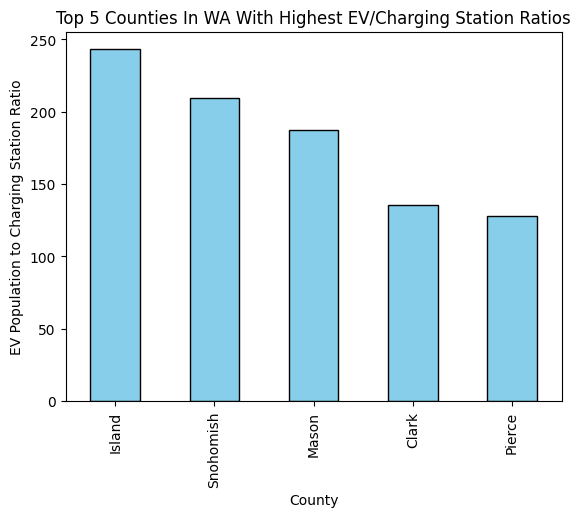

In [200]:
# Ensure the index is set to County to make bar graph more digestible
top_5.set_index('County', inplace=True)

# Plot a bar graph based on the 'V_to_S_Ratio' column
ax = top_5['V_to_S_Ratio'].plot(kind='bar', color='skyblue', edgecolor='black')

# Label the bar graph appropriately
plt.xlabel('County')
plt.ylabel('EV Population to Charging Station Ratio')
plt.title('Top 5 Counties In WA With Highest EV/Charging Station Ratios')
plt.show()

*Answer to research question:* **It appears that Island, Snohomish, Mason, Clark, and Pierce counties have the highest EV to Charging Station ratios in WA state.** These high ratios might indicate a broader need for additional charging stations in these communities!

That said, there are other variables to consider, such as overall EV population. Although Island County contains the highest ratio, the bar graph above does not indicate which of the five counties has the highest EV population overall. The more populous counties might stand to benefit more than counties which have a low overall EV population.

Let us explore a bivariate plot which includes overall EV population; this might provide more insight into which counties might realize greater benefits from added EV charging infrastructure.

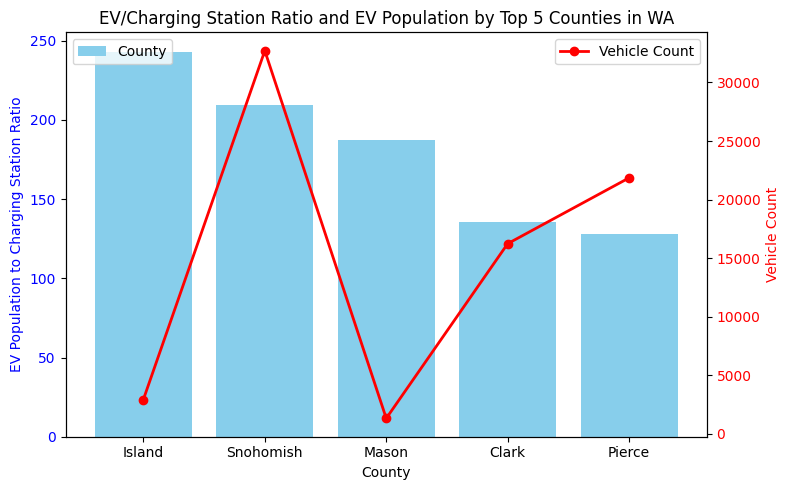

In [201]:
# Reset the top_5 dataframe so that 'County' is no longer the index
top_5 = merged_df.sort_values(by='V_to_S_Ratio',ascending=False).head(5)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(8,5))

# Plot bar chart for V_to_S_Ratio
ax1.bar(top_5['County'], top_5['V_to_S_Ratio'], color='skyblue', label='County')
ax1.set_xlabel('County')
ax1.set_ylabel('EV Population to Charging Station Ratio', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary y-axis and plot line for Vehicle Count
ax2 = ax1.twinx()
ax2.plot(top_5['County'], top_5['Vehicle Count'], color='red', marker='o', linewidth=2, label='Vehicle Count')
ax2.set_ylabel('Vehicle Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Position legends for both variables
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Label bar graph appropriately
plt.title('EV/Charging Station Ratio and EV Population by Top 5 Counties in WA')
plt.tight_layout()
plt.show()

*Answer to research question:* Here, we can see that of the 5 counties with the highest EV to charging station ratios in Washington, **Snohomish, Pierce, and Clark counties** have substantially higher EV populations than the others; this might indicate a greater overall need for added EV charging infrastructure within these regions.

### **5.2:** Reflection

If I had more time to work on this project, I would explore aggregating and comparing other variables (e.g. by city, instead of by county). There are variables in the original datasets which contain larger text strings; perhaps those could have been better formatted or standardized. If time permitted, I would further examine the relationships between make and model, privately/publicly owned charging facilities, prevalence of 24-hour facilities, and differences in cost of using charging stations.